# Import

In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import recall_score

# Install catboost if not already installed
try:
    from catboost import CatBoostClassifier
except ImportError:
    %pip install catboost
    from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


Data Load and Preprocesing

In [2]:
#Loading the dataset

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')



In [3]:
#First 5 records of the train dataset

print("*******Train data set top 5********:",df_train.head())


*******Train data set top 5********:      Id                           Prospect ID  Lead Number  \
0  1755  db9312a1-c65f-4a0c-a1e9-e82c65bb74b2       642295   
1  8085  d86d22e7-48f9-4353-a8ac-e333e6d30dec       588007   
2   426  19a4a1ae-3250-4758-aa69-30009d13c3d0       655793   
3  1214  25b42209-53e9-4818-8c62-55d545dc4d18       647039   
4  2714  79fe04d1-9678-47a0-8347-2f5e89990c39       633646   

               Lead Origin     Lead Source Do Not Email Do Not Call  \
0  Landing Page Submission          Google           No          No   
1            Lead Add Form       Reference           No          No   
2  Landing Page Submission          Google           No          No   
3  Landing Page Submission  Organic Search           No          No   
4  Landing Page Submission  Direct Traffic           No          No   

   Converted  TotalVisits  Total Time Spent on Website  ...  \
0          0          4.0                          198  ...   
1          1          0.0            

In [4]:
#first 5 records of test dataset

print("******Test data set top 5****:",df_test.head())

******Test data set top 5****:      Id                           Prospect ID  Lead Number  \
0  8305  54eb2a3d-cb6b-4616-b6e9-c80d8a9dbca4       586427   
1  1591  0ca87aef-fa6a-4b3c-acf7-36c1520e8a53       643772   
2  8604  6c3e541e-0a1a-4636-b4fa-d026488a33ac       584076   
3  1333  fff49ad0-6015-448c-a7cc-f454c39ffdda       645818   
4  4260  f880fcdd-3d15-408d-a716-e71801a6c420       619066   

               Lead Origin     Lead Source Do Not Email Do Not Call  \
0                      API      Olark Chat           No          No   
1                      API          Google           No          No   
2  Landing Page Submission          Google           No          No   
3  Landing Page Submission  Direct Traffic           No          No   
4  Landing Page Submission  Direct Traffic           No          No   

   TotalVisits  Total Time Spent on Website  Page Views Per Visit  ...  \
0          0.0                            0                   0.0  ...   
1          2.0       

In [5]:
#No of columns and rows in the train dataset
df_train.shape

(6468, 38)

In [6]:
#No of columns and rows in the test dataset
df_test.shape

(2772, 37)

In [7]:

print("****Train*****",df_train.info())
print("####Train#####",df_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 38 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Id                                             6468 non-null   int64  
 1   Prospect ID                                    6468 non-null   object 
 2   Lead Number                                    6468 non-null   int64  
 3   Lead Origin                                    6468 non-null   object 
 4   Lead Source                                    6442 non-null   object 
 5   Do Not Email                                   6468 non-null   object 
 6   Do Not Call                                    6468 non-null   object 
 7   Converted                                      6468 non-null   int64  
 8   TotalVisits                                    6367 non-null   float64
 9   Total Time Spent on Website                    6468 

In [8]:
#Describing statistical info of train dataset

print("Statistical info on Train dataset:",df_train.describe())
print("Statistical info on Test dataset:",df_test.describe())

Statistical info on Train dataset:                 Id    Lead Number    Converted  TotalVisits  \
count  6468.000000    6468.000000  6468.000000  6367.000000   
mean   4596.919759  617391.219697     0.385436     3.413853   
std    2670.784121   23459.006051     0.486736     5.033449   
min       0.000000  579533.000000     0.000000     0.000000   
25%    2280.750000  596490.500000     0.000000     1.000000   
50%    4584.500000  615811.000000     0.000000     3.000000   
75%    6928.500000  637663.000000     1.000000     5.000000   
max    9239.000000  660737.000000     1.000000   251.000000   

       Total Time Spent on Website  Page Views Per Visit  \
count                  6468.000000           6367.000000   
mean                    486.475881              2.363868   
std                     545.703612              2.216209   
min                       0.000000              0.000000   
25%                      11.000000              1.000000   
50%                     251.000000   

In [9]:
#Check the unique values for the columns Id, Prospect ID, Lead Number in train .


df_train[['Id','Prospect ID','Lead Number']].nunique()

,0
Id,6468
Prospect ID,6468
Lead Number,6468


In [10]:
#Check the unique values for the columns Id, Prospect ID, Lead Number in train
df_test[['Id','Prospect ID','Lead Number']].nunique()

,0
Id,2772
Prospect ID,2772
Lead Number,2772


In [11]:
df_train.drop(['Prospect ID','Lead Number'],axis=1,inplace=True, errors='ignore')
df_test.drop(['Prospect ID','Lead Number'],axis=1,inplace=True, errors='ignore')

In [12]:
#Checking if Id has unique values in train

if df_train.Id.is_unique:
    print("Id is unique")      # execute when 'if' block will true
else:
    print("Id is not unique")  # execute when 'else' block will true

Id is unique


In [13]:
#Checking if Id has unique values in test
if df_test.Id.is_unique:
    print("Id is unique")      # execute when 'if' block will true
else:
    print("Id is not unique") # execute when 'else' block will true

Id is unique


In [14]:
#Verify if the columns are removed

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 36 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Id                                             6468 non-null   int64  
 1   Lead Origin                                    6468 non-null   object 
 2   Lead Source                                    6442 non-null   object 
 3   Do Not Email                                   6468 non-null   object 
 4   Do Not Call                                    6468 non-null   object 
 5   Converted                                      6468 non-null   int64  
 6   TotalVisits                                    6367 non-null   float64
 7   Total Time Spent on Website                    6468 non-null   int64  
 8   Page Views Per Visit                           6367 non-null   float64
 9   Last Activity                                  6394 

In [15]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 35 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Id                                             2772 non-null   int64  
 1   Lead Origin                                    2772 non-null   object 
 2   Lead Source                                    2762 non-null   object 
 3   Do Not Email                                   2772 non-null   object 
 4   Do Not Call                                    2772 non-null   object 
 5   TotalVisits                                    2736 non-null   float64
 6   Total Time Spent on Website                    2772 non-null   int64  
 7   Page Views Per Visit                           2736 non-null   float64
 8   Last Activity                                  2743 non-null   object 
 9   Country                                        2044 

In [16]:
#Check for null values in train
df_train.isnull().sum()

,0
Id,0
Lead Origin,0
Lead Source,26
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,101
Total Time Spent on Website,0
Page Views Per Visit,101
Last Activity,74


In [17]:
#Check for null values in train
df_test.isnull().sum()

,0
Id,0
Lead Origin,0
Lead Source,10
Do Not Email,0
Do Not Call,0
TotalVisits,36
Total Time Spent on Website,0
Page Views Per Visit,36
Last Activity,29
Country,728


In [18]:
#Checking for constant feature in train data

for col in df_train.columns:
    if df_train[col].nunique() == 1:
        print(col)

Magazine
Receive More Updates About Our Courses
Update me on Supply Chain Content
Get updates on DM Content
I agree to pay the amount through cheque


In [19]:
#Checking for constant feature in test data

for col in df_test.columns:
    if df_test[col].nunique() == 1:
        print(col)

Do Not Call
Magazine
X Education Forums
Newspaper
Digital Advertisement
Receive More Updates About Our Courses
Update me on Supply Chain Content
Get updates on DM Content
I agree to pay the amount through cheque


In [20]:
#The colums below has unique value 'No'. There is no variation to learn from. So dropped
unique_value_cols_to_drop = [
    'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'I agree to pay the amount through cheque',
    'Digital Advertisement'
]
df_train.drop(columns=unique_value_cols_to_drop, axis=1, inplace=True, errors='ignore')
df_test.drop(columns=unique_value_cols_to_drop, axis=1, inplace=True, errors='ignore')

print("Columns dropped successfully.")
print(f"Remaining columns in df_train: {df_train.shape[1]}")
print(f"Remaining columns in df_test: {df_test.shape[1]}")



Columns dropped successfully.
Remaining columns in df_train: 31
Remaining columns in df_test: 30


In [21]:
# Dropping remaining low-variance columns
low_variance_cols_to_drop = [
    'Magazine',
    'Search',
    'Newspaper Article',
    'X Education Forums',
    'Newspaper',
    # 'Digital Advertisement',
    # 'Through Recommendations',
    # 'What matters most to you in choosing a course'
]

df_train.drop(columns=low_variance_cols_to_drop, axis=1, inplace=True, errors='ignore')
df_test.drop(columns=low_variance_cols_to_drop, axis=1, inplace=True, errors='ignore')

print("Columns dropped successfully.")
print(f"Remaining columns in df_train: {df_train.shape[1]}")
print(f"Remaining columns in df_test: {df_test.shape[1]}")

Columns dropped successfully.
Remaining columns in df_train: 26
Remaining columns in df_test: 25


In [22]:
#Get the columns whose datatype is object in train datast
object_col = df_train.select_dtypes(include=['object']).columns
# print(obj_col)

for col in object_col:
    print(col)
    print(df_train[col].value_counts())
    print('*'*120)

Lead Origin
Lead Origin
Landing Page Submission    3411
API                        2503
Lead Add Form               513
Lead Import                  40
Quick Add Form                1
Name: count, dtype: int64
************************************************************************************************************************
Lead Source
Lead Source
Google              2004
Direct Traffic      1787
Olark Chat          1219
Organic Search       797
Reference            387
Welingak Website     101
Referral Sites        94
Facebook              40
google                 4
bing                   2
Press_Release          2
testone                1
Click2call             1
WeLearn                1
Live Chat              1
welearnblog_Home       1
Name: count, dtype: int64
************************************************************************************************************************
Do Not Email
Do Not Email
No     5938
Yes     530
Name: count, dtype: int64
**********************

In [23]:
#Get the columns whose datatype is object in test dataset
object_col = df_test.select_dtypes(include=['object']).columns
# print(obj_col)

for col in object_col:
    print(col)
    print(df_test[col].value_counts())
    print('*'*120)

Lead Origin
Lead Origin
Landing Page Submission    1475
API                        1077
Lead Add Form               205
Lead Import                  15
Name: count, dtype: int64
************************************************************************************************************************
Lead Source
Lead Source
Google               864
Direct Traffic       756
Olark Chat           536
Organic Search       357
Reference            147
Welingak Website      41
Referral Sites        31
Facebook              15
bing                   4
Click2call             3
Social Media           2
Pay per Click Ads      1
google                 1
blog                   1
Live Chat              1
NC_EDM                 1
youtubechannel         1
Name: count, dtype: int64
************************************************************************************************************************
Do Not Email
Do Not Email
No     2568
Yes     204
Name: count, dtype: int64
*****************************

In [24]:
pd.crosstab(df_train['Do Not Email'], df_train['Converted'])

Converted,0,1
Do Not Email,,
No,3525,2413
Yes,450,80


In [25]:
#After analyzing the Do Not Email(keep it because its predictive) and Do Not Call(drop it) have decided to remove 'Do Not call' because only 2 records against
#6468 records. It will not contribute meaningful predictive information.

df_train.drop('Do Not Call',axis=1,inplace=True, errors='ignore')
df_test.drop('Do Not Call',axis=1,inplace=True, errors='ignore')




<Axes: title={'center': 'Coversion'}, xlabel='Converted', ylabel='count'>

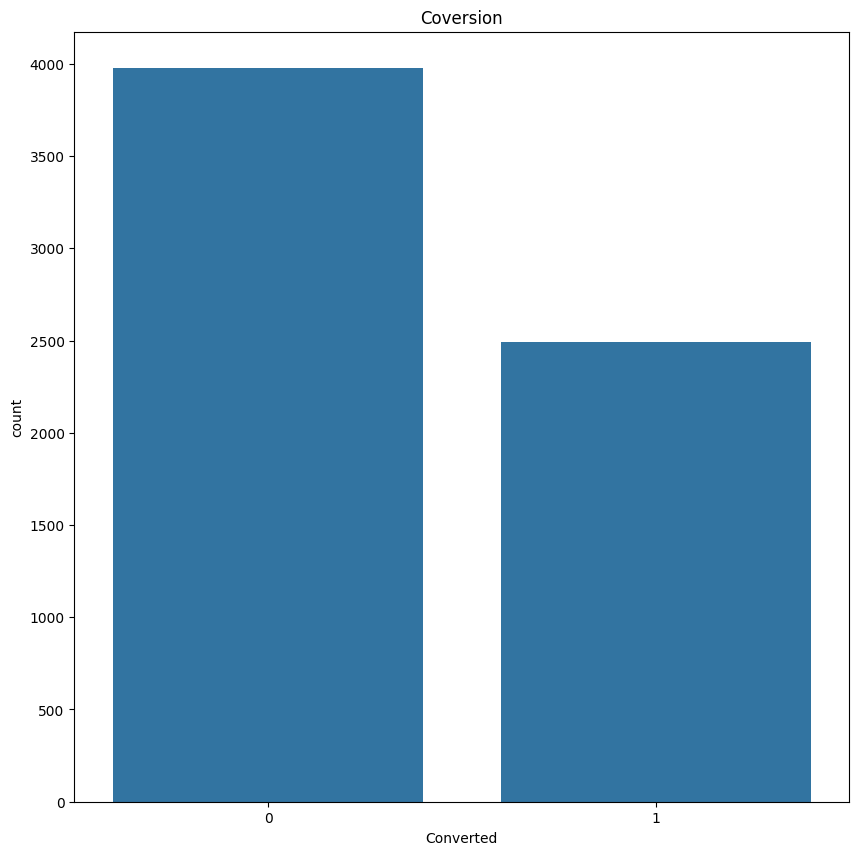

In [26]:
#Check for the data balance
plt.figure(figsize=(10,10))
plt.title('Coversion')
snb.countplot(x='Converted',data=df_train)

In [27]:
# Re-get object columns after previous drops
obj_col = df_train.select_dtypes(include=['object']).columns

for col in obj_col:
    print(f"{col}: {df_train[col].nunique()} unique values")

Lead Origin: 5 unique values
Lead Source: 16 unique values
Do Not Email: 2 unique values
Last Activity: 14 unique values
Country: 33 unique values
Specialization: 19 unique values
How did you hear about X Education: 10 unique values
What is your current occupation: 6 unique values
What matters most to you in choosing a course: 2 unique values
Through Recommendations: 2 unique values
Tags: 26 unique values
Lead Quality: 5 unique values
Lead Profile: 6 unique values
City: 7 unique values
Asymmetrique Activity Index: 3 unique values
Asymmetrique Profile Index: 3 unique values
A free copy of Mastering The Interview: 2 unique values
Last Notable Activity: 12 unique values


There are 18 colums with multiple entries. Check for the relation of these columns with Conversion. If there are unique values or rare categroies we can drop them since the model will not have enough observations to predict.

In [28]:
# <<1>> Lead Origin. This column has influence on the output.
pd.crosstab(df_train['Lead Origin'], df_train['Converted'])

Converted,0,1
Lead Origin,,
API,1712,791
Landing Page Submission,2194,1217
Lead Add Form,37,476
Lead Import,32,8
Quick Add Form,0,1


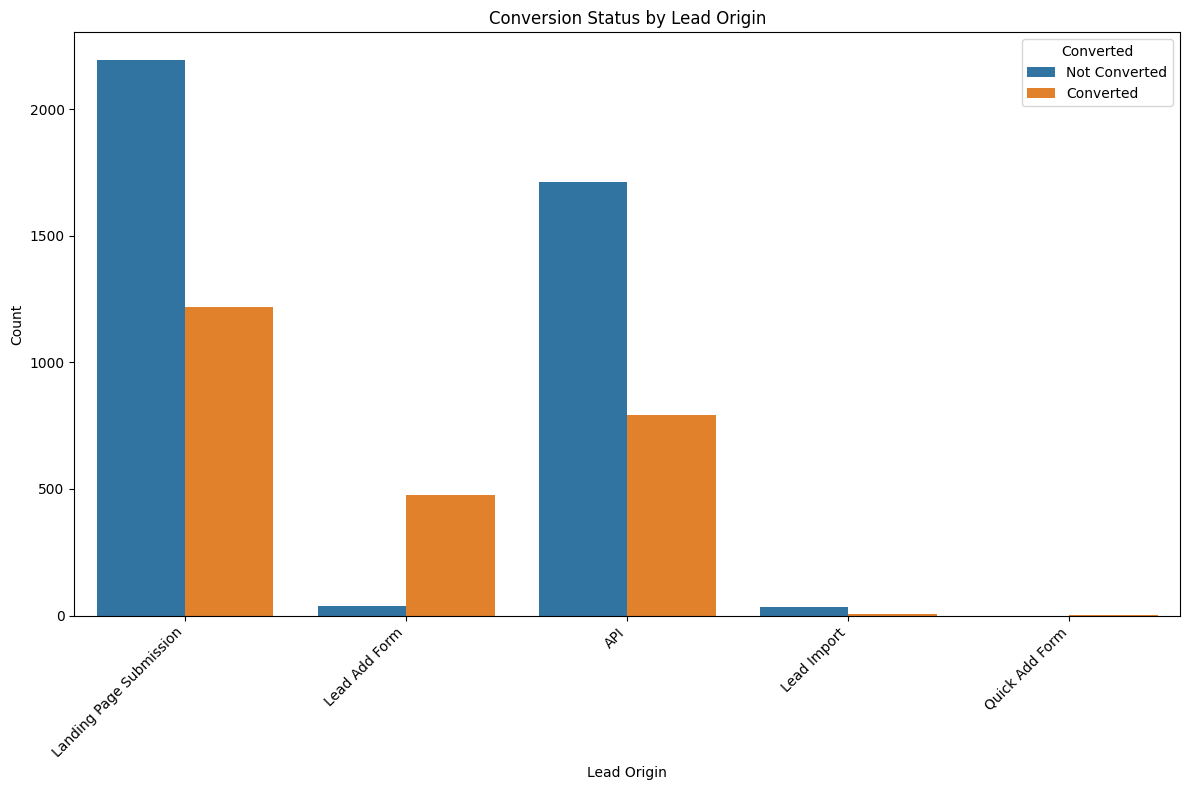

In [29]:
plt.figure(figsize=(12, 8))
snb.countplot(x='Lead Origin', hue='Converted', data=df_train)
plt.title('Conversion Status by Lead Origin')
plt.xlabel('Lead Origin')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Converted', labels=['Not Converted', 'Converted'])
plt.tight_layout()
plt.show()

In [30]:
#<<2>> Lead source. Google and google needs to be merged. Rare categories will be merged to 'Other'
pd.crosstab(df_train['Lead Source'], df_train['Converted'])


Converted,0,1
Lead Source,,
Click2call,0,1
Direct Traffic,1209,578
Facebook,32,8
Google,1207,797
Live Chat,0,1
Olark Chat,916,303
Organic Search,493,304
Press_Release,2,0
Reference,29,358


In [31]:
#Google and google represent same source
df_train['Lead Source'] = df_train['Lead Source'].replace('Google', 'google')
df_test['Lead Source'] = df_test['Lead Source'].replace('Google', 'google')

In [32]:
#Merge rare categories
threshold = 10

counts = df_train['Lead Source'].value_counts()

rare = counts[counts < threshold].index

df_train['Lead Source'] = df_train['Lead Source'].replace(rare, 'Other')
df_test['Lead Source'] = df_test['Lead Source'].replace(rare, 'Other')

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

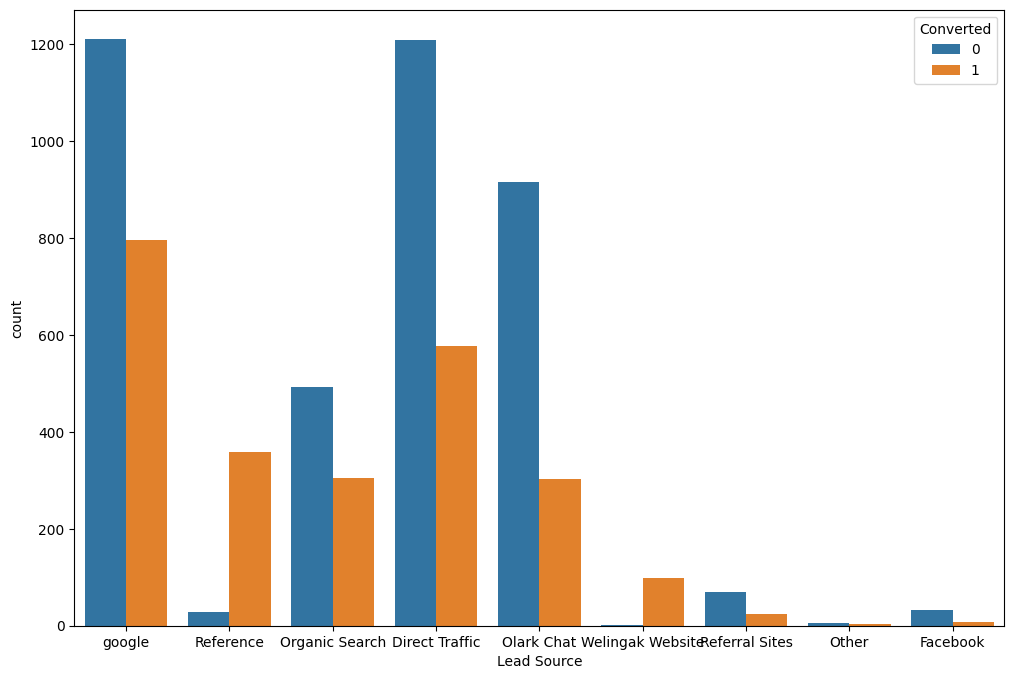

In [33]:
#Plot the graph to check the relation
plt.figure(figsize=(12, 8))
snb.countplot(x='Lead Source', hue='Converted', data=df_train)
plt

In [34]:
#<<3>>Last Activity
pd.crosstab(df_train['Last Activity'], df_train['Converted'])

Converted,0,1
Last Activity,,
Approached upfront,0,6
Converted to Lead,262,37
Email Bounced,223,16
Email Link Clicked,134,55
Email Opened,1536,867
Email Received,0,1
Form Submitted on Website,66,21
Had a Phone Conversation,6,21
Olark Chat Conversation,609,53


In [35]:
#Make a list of rare categories and then replace with "Other'

rare_categories_rows = ['Email Received', 'View in browser link Clicked', 'Approached upfront']

df_train['Last Activity'] = df_train['Last Activity'].replace(rare_categories_rows, 'Other')
df_test['Last Activity'] = df_test['Last Activity'].replace(rare_categories_rows, 'Other')

<Axes: xlabel='Last Activity', ylabel='count'>

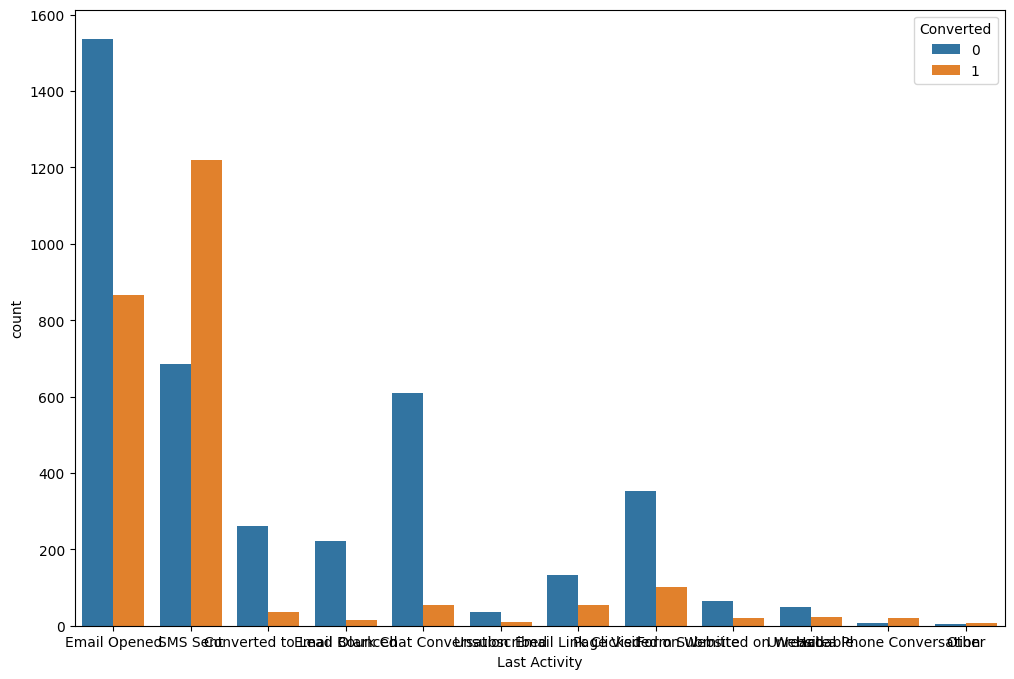

In [36]:
#Plot the relation graph with Last Activity and Converted

plt.figure(figsize=(12, 8))
snb.countplot(x='Last Activity', hue='Converted', data=df_train)

In [37]:
print('Updated cross-tabulation for Last Activity:')
pd.crosstab(df_train['Last Activity'], df_train['Converted'])

Updated cross-tabulation for Last Activity:


Converted,0,1
Last Activity,,
Converted to Lead,262,37
Email Bounced,223,16
Email Link Clicked,134,55
Email Opened,1536,867
Form Submitted on Website,66,21
Had a Phone Conversation,6,21
Olark Chat Conversation,609,53
Other,4,8
Page Visited on Website,352,102


In [38]:
# <<4>>Country. Check for rare categories and group to other

pd.crosstab(df_train['Country'], df_train['Converted'])


Converted,0,1
Country,,
Asia/Pacific Region,1,0
Australia,8,2
Bahrain,3,3
Bangladesh,0,1
Belgium,2,0
Canada,1,0
China,1,0
Denmark,0,1
France,3,3


In [39]:
#Check for rare categories and replace with 'Other'

threshold = 5

counts = df_train['Country'].value_counts()

rare = counts[counts < threshold].index

df_train['Country'] = df_train['Country'].replace(rare, 'Other')
df_test['Country'] = df_test['Country'].replace(rare, 'Other')

In [40]:
print('Updated cross-tabulation for Country:')
pd.crosstab(df_train['Country'], df_train['Converted'])

Updated cross-tabulation for Country:


Converted,0,1
Country,,
Australia,8,2
Bahrain,3,3
France,3,3
Hong Kong,2,3
India,2867,1679
Other,29,5
Qatar,4,1
Saudi Arabia,7,1
Singapore,11,5


In [41]:
#<<5>> Specialization
pd.crosstab(df_train['Specialization'], df_train['Converted'])

Converted,0,1
Specialization,,
"Banking, Investment And Insurance",123,106
Business Administration,148,125
E-Business,24,13
E-COMMERCE,54,25
Finance Management,387,306
Healthcare Management,50,60
Hospitality Management,48,36
Human Resource Management,324,273
IT Projects Management,149,89


<Axes: xlabel='Specialization', ylabel='count'>

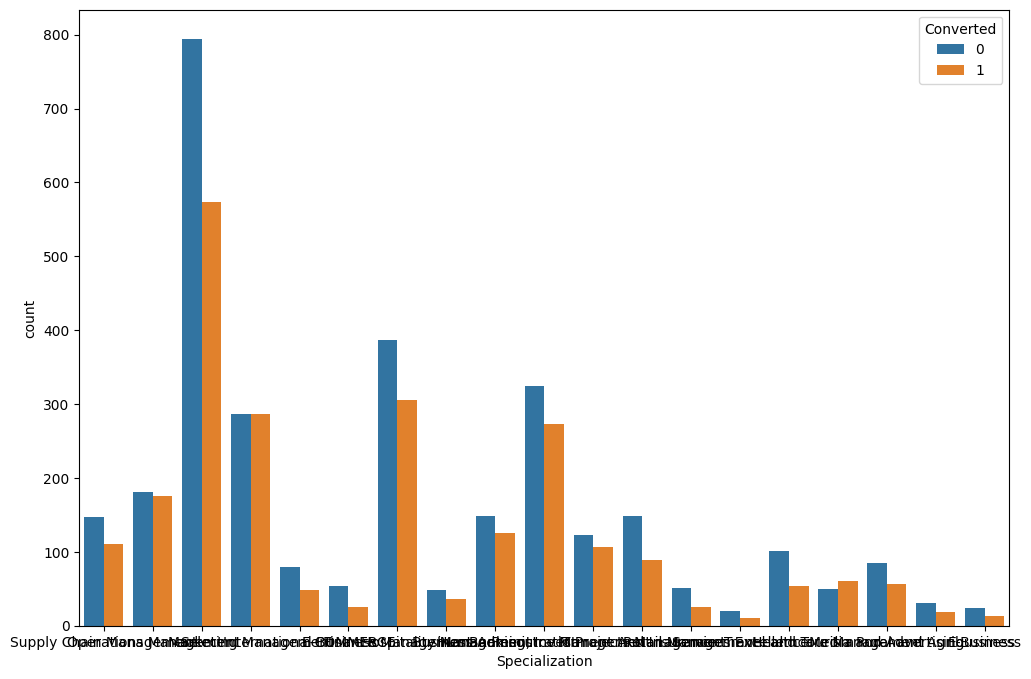

In [42]:
#Plot the graph to see the relation with Coverted

plt.figure(figsize=(12, 8))
snb.countplot(x='Specialization', hue='Converted', data=df_train)

In [43]:
#<<6>>How did you hear about X Education
pd.crosstab(df_train['How did you hear about X Education'], df_train['Converted'])

Converted,0,1
How did you hear about X Education,,
Advertisements,25,23
Email,10,10
Multiple Sources,59,40
Online Search,328,253
Other,83,46
SMS,12,4
Select,1827,1728
Social Media,31,20
Student of SomeSchool,126,88


<Axes: xlabel='How did you hear about X Education', ylabel='count'>

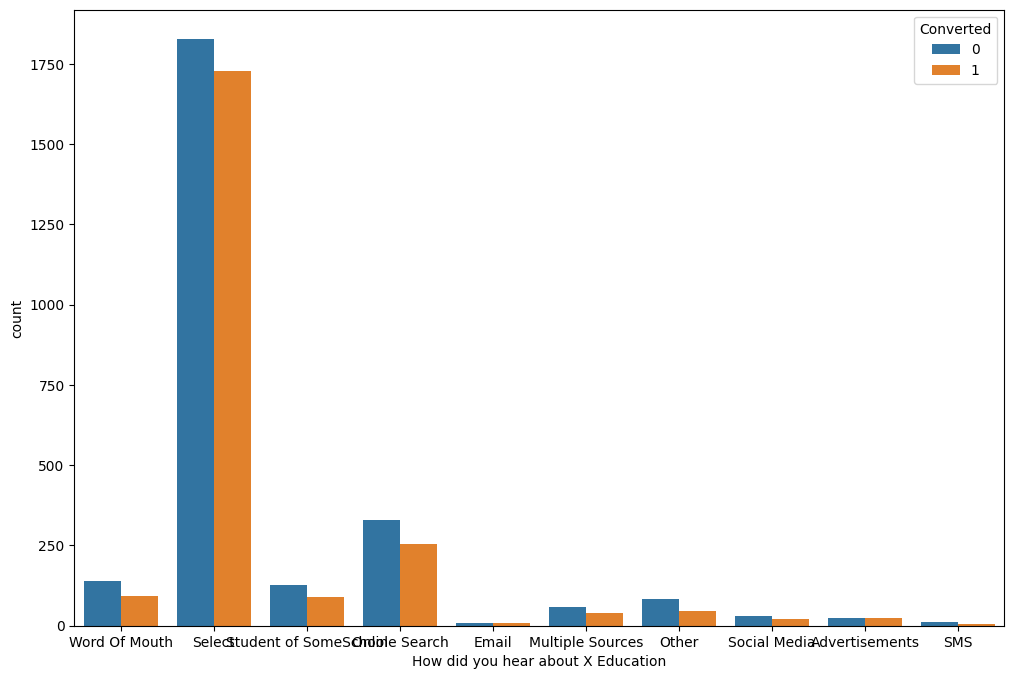

In [44]:
#Plot the graph to show the relation with Coverted

plt.figure(figsize=(12, 8))
snb.countplot(x='How did you hear about X Education', hue='Converted', data=df_train)


In [45]:
#<<7>>What is your current occupation
pd.crosstab(df_train['What is your current occupation'], df_train['Converted'])

Converted,0,1
What is your current occupation,,
Businessman,2,4
Housewife,0,6
Other,4,6
Student,93,54
Unemployed,2222,1716
Working Professional,36,471


<Axes: xlabel='What is your current occupation', ylabel='count'>

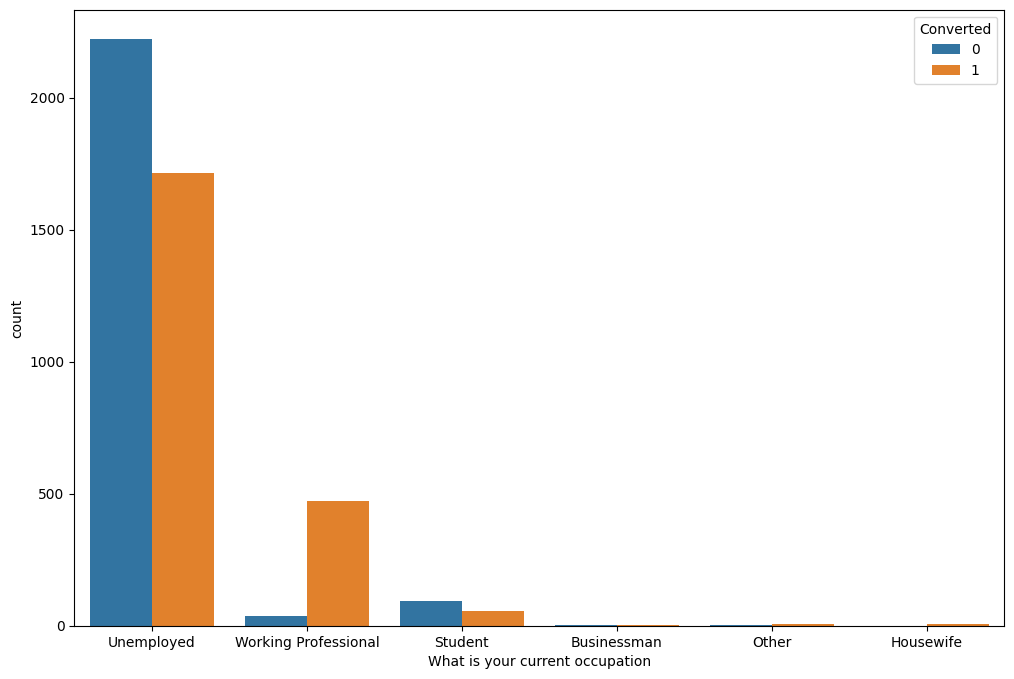

In [46]:
#Plot the realtion graph

plt.figure(figsize=(12, 8))
snb.countplot(x='What is your current occupation', hue='Converted', data=df_train)

In [47]:
#<<8>> What matters most to you in choosing a course
pd.crosstab(df_train['What matters most to you in choosing a course'], df_train['Converted'])

Converted,0,1
What matters most to you in choosing a course,,
Better Career Prospects,2343,2256
Flexibility & Convenience,1,1


In [48]:
#There is only one single entry for Flexibility & Convenience row. Model will not be able to learn from rere categories.
#Drop this column

df_train.drop('What matters most to you in choosing a course',axis=1,inplace=True, errors='ignore')
df_test.drop('What matters most to you in choosing a course',axis=1,inplace=True, errors='ignore')

In [49]:
#<<9>>Through Recommendations
pd.crosstab(df_train['Through Recommendations'], df_train['Converted'])

Converted,0,1
Through Recommendations,,
No,3974,2490
Yes,1,3


In [50]:
##There is rare categories entry. Model cant predict.
#Drop this column

df_train.drop('Through Recommendations',axis=1,inplace=True, errors='ignore')
df_test.drop('Through Recommendations',axis=1,inplace=True, errors='ignore')

In [51]:
#<<10>>Tags. Many rare categories. Group them as 'Other'
pd.crosstab(df_train['Tags'], df_train['Converted'])

Converted,0,1
Tags,,
Already a student,329,3
Busy,60,68
Closed by Horizzon,1,261
Diploma holder (Not Eligible),46,1
Graduation in progress,76,7
In confusion whether part time or DLP,1,1
Interested in full time MBA,78,1
Interested in Next batch,0,5
Interested in other courses,343,6


In [52]:
#Group the rare categories

threshold = 10

counts = df_train['Tags'].value_counts()

rare = counts[counts < threshold].index

df_train['Tags'] = df_train['Tags'].replace(rare, 'Other')
df_test['Tags'] = df_test['Tags'].replace(rare, 'Other')


In [53]:
print('Updated cross-tabulation for Tags:')
pd.crosstab(df_train['Tags'], df_train['Converted'])

Updated cross-tabulation for Tags:


Converted,0,1
Tags,,
Already a student,329,3
Busy,60,68
Closed by Horizzon,1,261
Diploma holder (Not Eligible),46,1
Graduation in progress,76,7
Interested in full time MBA,78,1
Interested in other courses,343,6
Lost to EINS,1,113
Not doing further education,103,1


In [54]:
#<<11>Lead Quality
pd.crosstab(df_train['Lead Quality'], df_train['Converted'])

Converted,0,1
Lead Quality,,
High in Relevance,24,422
Low in Relevance,70,339
Might be,267,856
Not Sure,587,174
Worst,414,6


<Axes: xlabel='Lead Quality', ylabel='count'>

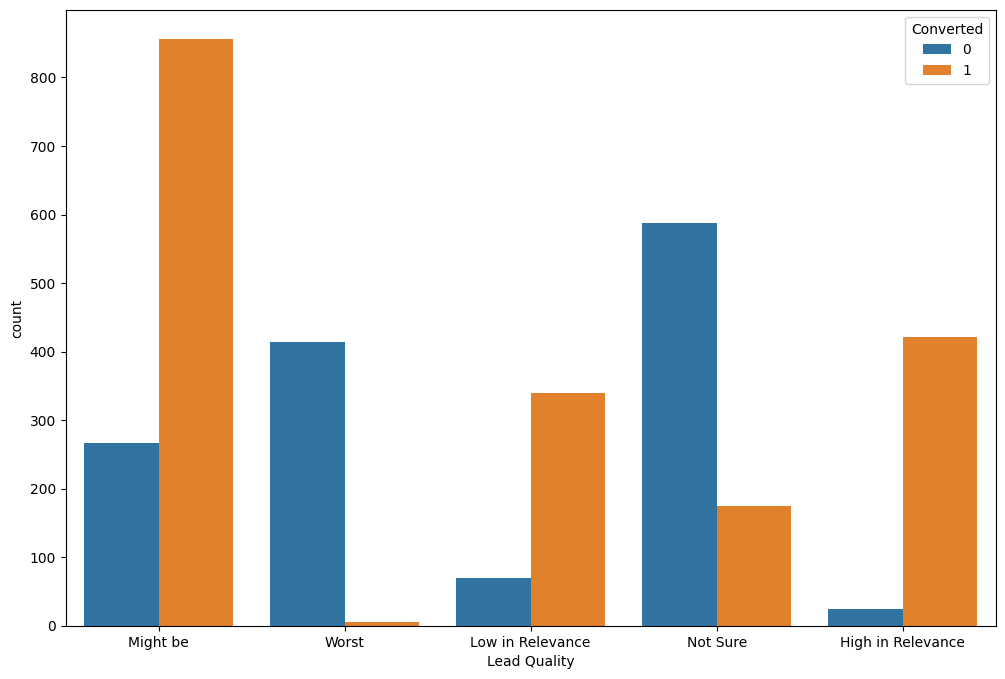

In [55]:
#Plot the graph

plt.figure(figsize=(12, 8))
snb.countplot(x='Lead Quality', hue='Converted', data=df_train)

In [56]:
#<<12>>Lead Profile
pd.crosstab(df_train['Lead Profile'], df_train['Converted'])

Converted,0,1
Lead Profile,,
Dual Specialization Student,0,11
Lateral Student,1,16
Other Leads,218,126
Potential Lead,249,899
Select,1712,1201
Student of SomeSchool,164,4


In [57]:
#<<13>City

pd.crosstab(df_train['City'], df_train['Converted'])

Converted,0,1
City,,
Mumbai,1365,898
Other Cities,289,200
Other Cities of Maharashtra,180,145
Other Metro Cities,149,104
Select,806,782
Thane & Outskirts,278,240
Tier II Cities,34,18


In [58]:
#<<14>>Asymmetrique Activity Index
pd.crosstab(df_train['Asymmetrique Activity Index'], df_train['Converted'])

Converted,0,1
Asymmetrique Activity Index,,
01.High,403,170
02.Medium,1572,1128
03.Low,235,27


<Axes: xlabel='Asymmetrique Activity Index', ylabel='count'>

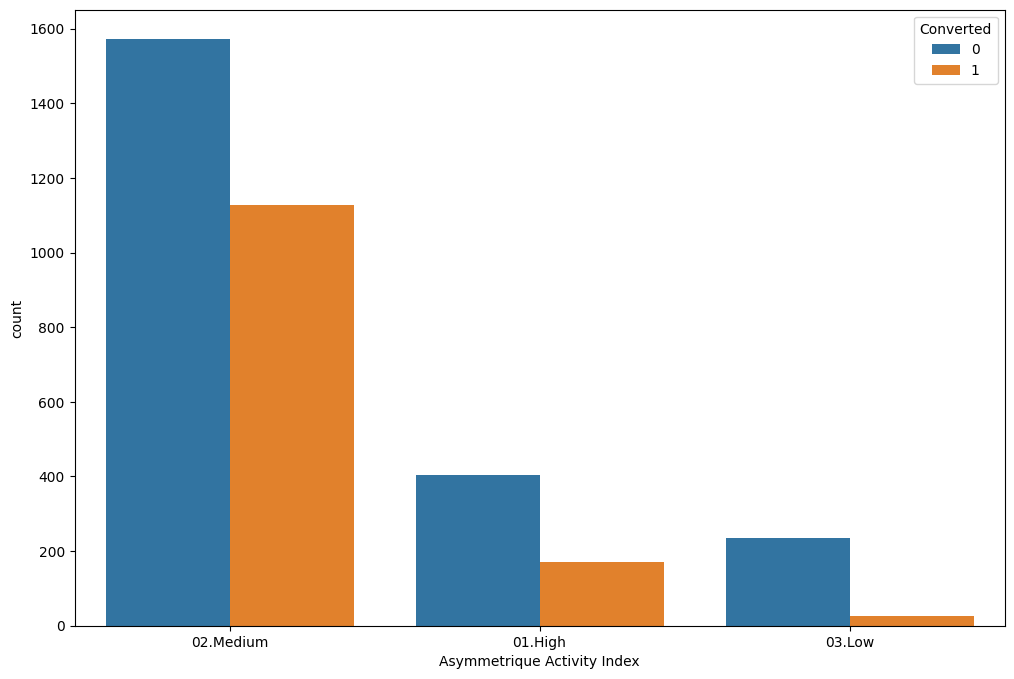

In [59]:
#Plot graph

plt.figure(figsize=(12, 8))
snb.countplot(x='Asymmetrique Activity Index', hue='Converted', data=df_train)

In [60]:
#<15>>Asymmetrique Profile Index
pd.crosstab(df_train['Asymmetrique Profile Index'], df_train['Converted'])

Converted,0,1
Asymmetrique Profile Index,,
01.High,826,709
02.Medium,1370,607
03.Low,14,9


In [61]:
#<16>A free copy of Mastering The Interview
pd.crosstab(df_train['A free copy of Mastering The Interview'], df_train['Converted'])

Converted,0,1
A free copy of Mastering The Interview,,
No,2676,1778
Yes,1299,715


In [62]:
#<17>Last Notable Activity, There are few rare category rows.
pd.crosstab(df_train['Last Notable Activity'], df_train['Converted'])

Converted,0,1
Last Notable Activity,,
Email Bounced,37,6
Email Link Clicked,89,36
Email Opened,1264,718
Email Received,0,1
Form Submitted on Website,1,0
Had a Phone Conversation,0,12
Modified,1828,558
Olark Chat Conversation,109,16
Page Visited on Website,172,58


In [63]:
#Regroup the rare categories to Other

threshold =  10

counts = df_train['Last Notable Activity'].value_counts()

rare = counts[counts < threshold].index

df_train['Last Notable Activity'] = df_train['Last Notable Activity'].replace(rare, 'Other')



In [64]:
print('Updated cross-tabulation for Last Notable Activity:')
pd.crosstab(df_train['Last Notable Activity'], df_train['Converted'])

Updated cross-tabulation for Last Notable Activity:


Converted,0,1
Last Notable Activity,,
Email Bounced,37,6
Email Link Clicked,89,36
Email Opened,1264,718
Had a Phone Conversation,0,12
Modified,1828,558
Olark Chat Conversation,109,16
Other,1,1
Page Visited on Website,172,58
SMS Sent,441,1065


Check for dtype Object and then do encoding (binary, orderly, hot encoding)

In [65]:
#Print all the columsn where the dtbype is Object

obj_col = df_train.select_dtypes(include=['object']).columns
print(obj_col)



Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation', 'Tags', 'Lead Quality',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'A free copy of Mastering The Interview',
       'Last Notable Activity'],
      dtype='object')


In [66]:
obj_cols = df_train.select_dtypes(include=['object']).columns

for col in obj_cols:
    print(f"\nValue counts for column: {col}")
    print(df_train[col].value_counts())
    print("-"*50)


Value counts for column: Lead Origin
Lead Origin
Landing Page Submission    3411
API                        2503
Lead Add Form               513
Lead Import                  40
Quick Add Form                1
Name: count, dtype: int64
--------------------------------------------------

Value counts for column: Lead Source
Lead Source
google              2008
Direct Traffic      1787
Olark Chat          1219
Organic Search       797
Reference            387
Welingak Website     101
Referral Sites        94
Facebook              40
Other                  9
Name: count, dtype: int64
--------------------------------------------------

Value counts for column: Do Not Email
Do Not Email
No     5938
Yes     530
Name: count, dtype: int64
--------------------------------------------------

Value counts for column: Last Activity
Last Activity
Email Opened                 2403
SMS Sent                     1906
Olark Chat Conversation       662
Page Visited on Website       454
Converted to Lead 

In [67]:
#(1)#Do Not Email. Binary Encoding

print(df_train['Do Not Email'].value_counts())
print(df_test['Do Not Email'].value_counts())



Do Not Email
No     5938
Yes     530
Name: count, dtype: int64
Do Not Email
No     2568
Yes     204
Name: count, dtype: int64


In [68]:
#Binary Encoding

df_train['Do Not Email'] = df_train['Do Not Email'].map({'Yes': 1, 'No': 0})
df_test['Do Not Email'] = df_test['Do Not Email'].map({'Yes': 1, 'No': 0})



In [69]:
#(2) Binary encoding A free copy of Mastering The Interview
print(df_train['A free copy of Mastering The Interview'].value_counts())
print(df_test['A free copy of Mastering The Interview'].value_counts())

df_train['A free copy of Mastering The Interview'] = df_train['A free copy of Mastering The Interview'].map({'Yes': 1, 'No': 0})
df_test['A free copy of Mastering The Interview'] = df_test['A free copy of Mastering The Interview'].map({'Yes': 1, 'No': 0})


A free copy of Mastering The Interview
No     4454
Yes    2014
Name: count, dtype: int64
A free copy of Mastering The Interview
No     1898
Yes     874
Name: count, dtype: int64


In [70]:
#(3)Orderly encoding Asymmetrique Profile Index

print(df_train['Asymmetrique Profile Index'].value_counts())
print(df_test['Asymmetrique Profile Index'].value_counts())

mapping = {
    '03.Low': 0,
    '02.Medium': 1,
    '01.High': 2
}

df_train['Asymmetrique Profile Index'] = df_train['Asymmetrique Profile Index'].map(mapping)
df_test['Asymmetrique Profile Index'] = df_test['Asymmetrique Profile Index'].map(mapping)

Asymmetrique Profile Index
02.Medium    1977
01.High      1535
03.Low         23
Name: count, dtype: int64
Asymmetrique Profile Index
02.Medium    811
01.High      668
03.Low         8
Name: count, dtype: int64


In [71]:
#(4)Orderly encoding Asymmetrique Activity Index

print(df_train['Asymmetrique Activity Index'].value_counts())
print(df_test['Asymmetrique Activity Index'].value_counts())

mapping = {
    '03.Low': 0,
    '02.Medium': 1,
    '01.High': 2
}

df_train['Asymmetrique Activity Index'] = df_train['Asymmetrique Activity Index'].map(mapping)
df_test['Asymmetrique Activity Index'] = df_test['Asymmetrique Activity Index'].map(mapping)



Asymmetrique Activity Index
02.Medium    2700
01.High       573
03.Low        262
Name: count, dtype: int64
Asymmetrique Activity Index
02.Medium    1139
01.High       248
03.Low        100
Name: count, dtype: int64


In [72]:
print("Updated list of object-type columns in df_train:")
obj_cols_train = df_train.select_dtypes(include=['object']).columns
print(obj_cols_train.tolist())

print("\nUpdated list of object-type columns in df_test:")
obj_cols_test = df_test.select_dtypes(include=['object']).columns
print(obj_cols_test.tolist())

Updated list of object-type columns in df_train:
['Lead Origin', 'Lead Source', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'Tags', 'Lead Quality', 'Lead Profile', 'City', 'Last Notable Activity']

Updated list of object-type columns in df_test:
['Lead Origin', 'Lead Source', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'Tags', 'Lead Quality', 'Lead Profile', 'City', 'Last Notable Activity']


Now, let's apply One-Hot Encoding to these identified categorical columns using `pd.get_dummies`. We will use `drop_first=True` to avoid multicollinearity, and then align the dataframes to ensure both `df_train` and `df_test` have the same columns after encoding.

In [73]:
# Apply One-Hot Encoding to categorical columns
df_train_encoded = pd.get_dummies(df_train, columns=obj_cols_train.tolist(), drop_first=True)
df_test_encoded = pd.get_dummies(df_test, columns=obj_cols_test.tolist(), drop_first=True)

# Align columns - crucial for ensuring both dataframes have the same columns after one-hot encoding
# This handles cases where a category might exist in train but not test, or vice versa
df_train_encoded, df_test_encoded = df_train_encoded.align(df_test_encoded, join='left', axis=1)

# Fill any NaN values introduced by alignment (e.g., if a category exists in test but not train)
df_train = df_train_encoded.fillna(0)
df_test = df_test_encoded.fillna(0)

# Convert boolean columns (True/False) to integers (1/0)
for col in df_train.select_dtypes(include='bool').columns:
    df_train[col] = df_train[col].astype(int)
for col in df_test.select_dtypes(include='bool').columns:
    df_test[col] = df_test[col].astype(int)

print("One-Hot Encoding complete.")
print(f"Shape of df_train after encoding: {df_train.shape}")
print(f"Shape of df_test after encoding: {df_test.shape}")

# Display the first few rows of the encoded training data
display(df_train.head())

One-Hot Encoding complete.
Shape of df_train after encoding: (6468, 118)
Shape of df_test after encoding: (2772, 118)


,Id,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,...,Last Notable Activity_Email Link Clicked,Last Notable Activity_Email Opened,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Other,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed
0,1755,0,0,4.0,198,4.0,1.0,2.0,14.0,17.0,...,0,1,0,0,0,0,0,0,0,0
1,8085,0,1,0.0,0,0.0,1.0,2.0,14.0,19.0,...,0,0,0,1,0,0,0,0,0,0
2,426,0,1,2.0,1099,2.0,1.0,2.0,14.0,18.0,...,0,0,0,1,0,0,0,0,0,0
3,1214,0,1,4.0,1381,4.0,1.0,2.0,14.0,18.0,...,0,1,0,0,0,0,0,0,0,0
4,2714,0,1,8.0,1484,8.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0


In [74]:
print("Remaining object-type columns in df_train:")
print(df_train.select_dtypes(include=['object']).columns.tolist())

print("\nRemaining object-type columns in df_test:")
print(df_test.select_dtypes(include=['object']).columns.tolist())

Remaining object-type columns in df_train:
[]

Remaining object-type columns in df_test:
[]


The data file is processed and is now ready for taining. We will test this on various models and check the accuracy.

Prepare the input file for the model

In [75]:
#Prepare X_train, y_train, X_test, y_test
X_full = df_train.drop(['Converted', 'Id'], axis=1)
y_full = df_train['Converted']

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (5174, 116)
Shape of y_train: (5174,)
Shape of X_test: (1294, 116)
Shape of y_test: (1294,)


Standard Scalar to fit the training data

In [76]:
#Standard Scalar
#Create instance of standard scalar. Fit the trainng data

scaler = StandardScaler()
scaler.fit(X_train)

#Transform the training and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train data shape:", X_train_scaled.shape)
print("Test data shape:", X_test_scaled.shape)

Train data shape: (5174, 116)
Test data shape: (1294, 116)


Logistic Regression model

Logistic# New Section

#Logistic Regression

In [77]:
#Logistic Regression model

model_logistic_default= LogisticRegression()
model_logistic_default.fit(X_train_scaled, y_train)

y_pred = model_logistic_default.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

print(f"Classifiation Report: {classification_report(y_test, y_pred)}")

Accuracy: 0.93
Confusion Matrix:
[[756  34]
 [ 54 450]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.93      0.96      0.94       790
           1       0.93      0.89      0.91       504

    accuracy                           0.93      1294
   macro avg       0.93      0.92      0.93      1294
weighted avg       0.93      0.93      0.93      1294



AUC: 0.977319419328913


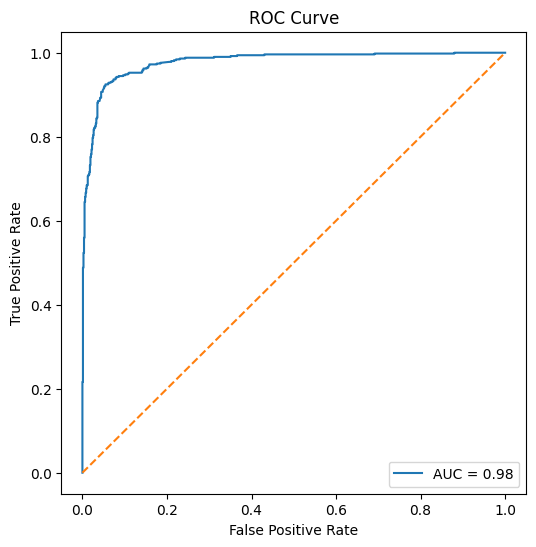

In [78]:
y_prob = model_logistic_default.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], '--')   # Random guessing line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [79]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [1000, 5000]
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)



print(f"Accuracy: {accuracy:.2f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

print(f"Classifiation Report: {classification_report(y_test, y_pred)}")


Best Hyperparameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.94
Confusion Matrix:
[[758  32]
 [ 50 454]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.94      0.96      0.95       790
           1       0.93      0.90      0.92       504

    accuracy                           0.94      1294
   macro avg       0.94      0.93      0.93      1294
weighted avg       0.94      0.94      0.94      1294



# KNN Model

In [80]:
#Knn Model

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

print(f"Classifiation Report: {classification_report(y_test, y_pred)}")

Accuracy: 0.86
Confusion Matrix:
[[738  52]
 [124 380]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.86      0.93      0.89       790
           1       0.88      0.75      0.81       504

    accuracy                           0.86      1294
   macro avg       0.87      0.84      0.85      1294
weighted avg       0.87      0.86      0.86      1294



In [81]:
#Find the best K value

k_values = list(range(1, 21))
accuracy_scores = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)
    y_pred = knn_model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    print(f"K={k} - Accuracy: {accuracy:.2f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"Classifiation Report: {classification_report(y_test, y_pred)}")
    print("-" * 50)

K=1 - Accuracy: 0.84
Confusion Matrix:
[[702  88]
 [119 385]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.86      0.89      0.87       790
           1       0.81      0.76      0.79       504

    accuracy                           0.84      1294
   macro avg       0.83      0.83      0.83      1294
weighted avg       0.84      0.84      0.84      1294

--------------------------------------------------
K=2 - Accuracy: 0.83
Confusion Matrix:
[[761  29]
 [186 318]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.80      0.96      0.88       790
           1       0.92      0.63      0.75       504

    accuracy                           0.83      1294
   macro avg       0.86      0.80      0.81      1294
weighted avg       0.85      0.83      0.83      1294

--------------------------------------------------
K=3 - Accuracy: 0.87
Confusion Matrix:
[[734  56]
 [116 388]]
Classifiation 

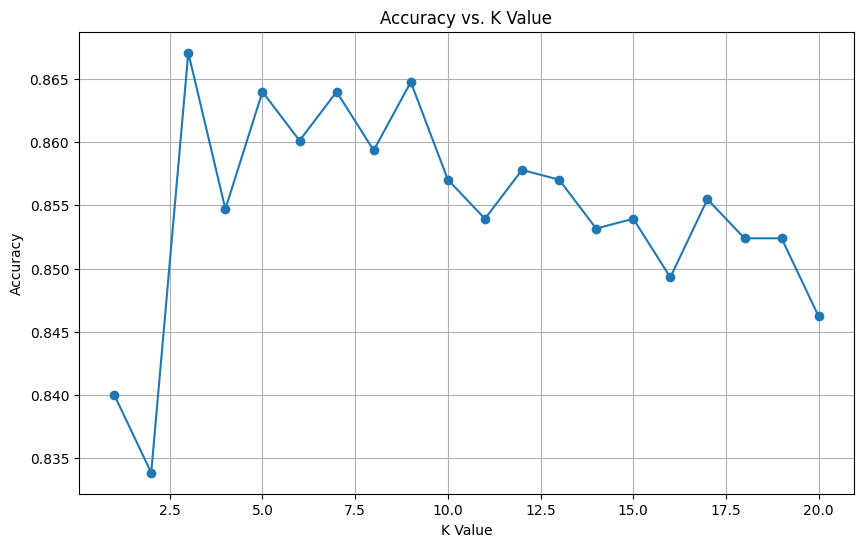

In [82]:
#Elbow method to find 'K'

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid(True)

In [83]:
# Re-train KNN model with optimal K=3
knn_model_optimal = KNeighborsClassifier(n_neighbors=3)
knn_model_optimal.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_optimal = knn_model_optimal.predict(X_test_scaled)

# Evaluate the model with K=3
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)
print(f"Accuracy with K=3: {accuracy_optimal:.2f}")
print(f"Confusion Matrix with K=3:\n{confusion_matrix(y_test, y_pred_optimal)}")
print(f"Classifiation Report with K=3: {classification_report(y_test, y_pred_optimal)}")

Accuracy with K=3: 0.87
Confusion Matrix with K=3:
[[734  56]
 [116 388]]
Classifiation Report with K=3:               precision    recall  f1-score   support

           0       0.86      0.93      0.90       790
           1       0.87      0.77      0.82       504

    accuracy                           0.87      1294
   macro avg       0.87      0.85      0.86      1294
weighted avg       0.87      0.87      0.87      1294



In [84]:
# Find the index of the maximum accuracy score
best_k_index = np.argmax(accuracy_scores)

# Get the corresponding K value
best_k = k_values[best_k_index]

print(f"The optimal K value is: {best_k}")

The optimal K value is: 3


AUC: 0.9040737392003215
AUC: 0.4977998794454491


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


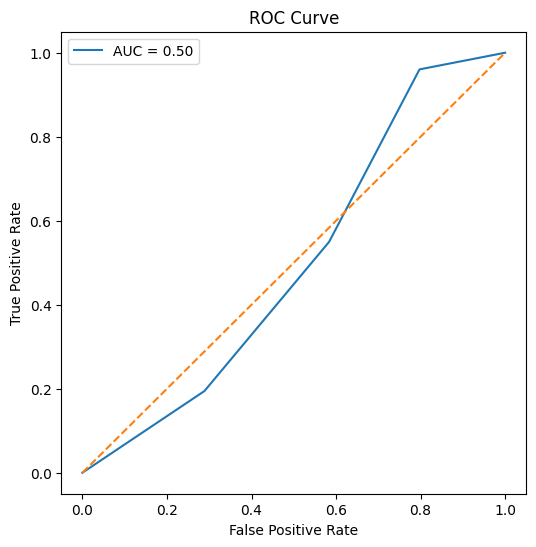

In [85]:
#Find the ROC-AOC curve and AOC value for KNN

y_prob = knn_model_optimal.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

y_prob = knn_model_optimal.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], '--')   # Random guessing line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# Decision Tree

In [86]:
#Decision Tree Model

dt_model_default = DecisionTreeClassifier(random_state=1)
dt_model_default.fit(X_train, y_train)

y_pred = dt_model_default.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

print(f"Classifiation Report: {classification_report(y_test, y_pred)}")



Accuracy: 0.91
Confusion Matrix:
[[729  61]
 [ 49 455]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.94      0.92      0.93       790
           1       0.88      0.90      0.89       504

    accuracy                           0.91      1294
   macro avg       0.91      0.91      0.91      1294
weighted avg       0.92      0.91      0.92      1294



AUC: 0.8641902752662246


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


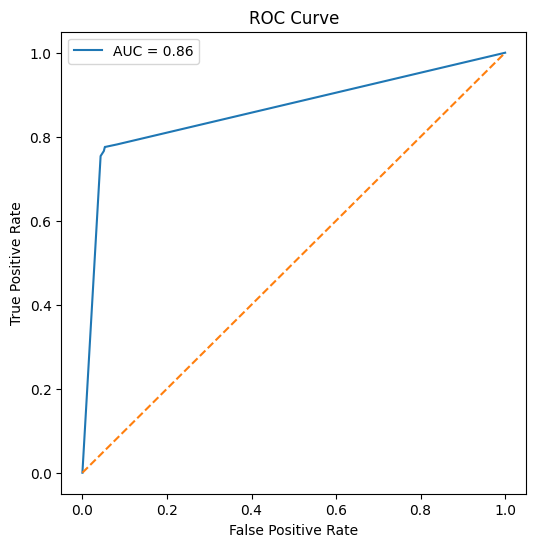

In [87]:
#Check ROC-AUC

y_prob = dt_model_default.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()







In [88]:
#Check accuracy by using Gini classifier and max depth 3

dt_model_gini = DecisionTreeClassifier(criterion='gini', max_depth=3 , random_state=0)
dt_model_gini.fit(X_train, y_train)

y_pred_gini = dt_model_gini.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gini)

print(f"Accuracy: {accuracy:.2f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_gini)}")

print(f"Classifiation Report: {classification_report(y_test, y_pred_gini)}")

Accuracy: 0.88
Confusion Matrix:
[[776  14]
 [147 357]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.84      0.98      0.91       790
           1       0.96      0.71      0.82       504

    accuracy                           0.88      1294
   macro avg       0.90      0.85      0.86      1294
weighted avg       0.89      0.88      0.87      1294



In [89]:
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.8756


In [90]:
#Check accuracy using entropy

dt_model_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3 , random_state=0)
dt_model_entropy.fit(X_train, y_train)

y_pred_entropy = dt_model_entropy.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_entropy)

print(f"Accuracy: {accuracy:.2f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_entropy)}")

print(f"Classifiation Report: {classification_report(y_test, y_pred_entropy)}")

Accuracy: 0.86
Confusion Matrix:
[[776  14]
 [169 335]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.82      0.98      0.89       790
           1       0.96      0.66      0.79       504

    accuracy                           0.86      1294
   macro avg       0.89      0.82      0.84      1294
weighted avg       0.88      0.86      0.85      1294



In [91]:
print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_entropy)))

Model accuracy score with criterion entropy: 0.8586


# RandomForest

In [92]:
#Train the model using RandomForest

rf_model_default = RandomForestClassifier(random_state=1)
rf_model_default.fit(X_train, y_train)

y_pred = rf_model_default.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

print(f"Classifiation Report: {classification_report(y_test, y_pred)}")

Accuracy: 0.93
Confusion Matrix:
[[753  37]
 [ 50 454]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.94      0.95      0.95       790
           1       0.92      0.90      0.91       504

    accuracy                           0.93      1294
   macro avg       0.93      0.93      0.93      1294
weighted avg       0.93      0.93      0.93      1294



AUC: 0.9521888185654008


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


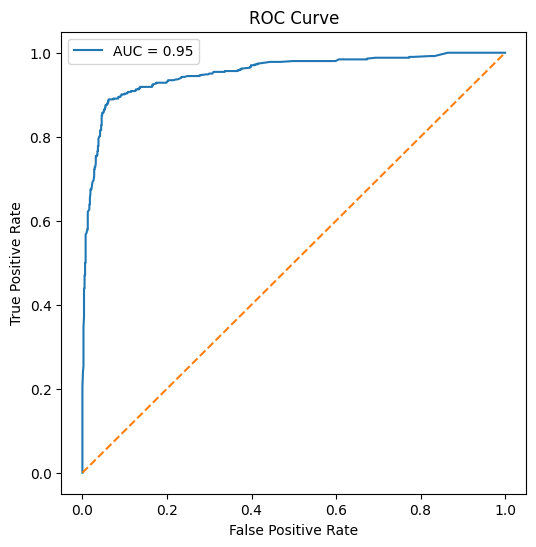

In [93]:
# Check ROC-AUC curve

y_prob = rf_model_default.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [94]:
#Create RandomForestClassufier instance
rf_classifier_instance = RandomForestClassifier(
    n_estimators=25, #No of decision tree
    max_features=6,# no of features to include during split
    criterion='gini',#Gini impurity for the quality of the split
    min_impurity_decrease=0.05,
    bootstrap=True,
    oob_score=True,
    class_weight='balanced',
    random_state=7)

rf_model_instance = rf_classifier_instance.fit(X_train, y_train)

y_pred = rf_model_instance.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

print(f"Classifiation Report: {classification_report(y_test, y_pred)}")





Accuracy: 0.79
Confusion Matrix:
[[656 134]
 [144 360]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.82      0.83      0.83       790
           1       0.73      0.71      0.72       504

    accuracy                           0.79      1294
   macro avg       0.77      0.77      0.77      1294
weighted avg       0.78      0.79      0.78      1294



In [95]:
# Create a RandomForestClassifier instance with specified hyperparameters
rf_classifier_param = RandomForestClassifier(
    n_estimators=25,  # Number of decision trees in the forest
    max_features=6,  # Maximum number of features considered for splitting
    criterion='gini',  # The function to measure the quality of a split (Gini impurity)
    max_depth=10,  # Maximum depth of the decision trees
    min_impurity_decrease=0.01,  # Minimum impurity decrease required for a split
    bootstrap=True,  # Whether bootstrap samples are used when building trees
    oob_score=True,  # Whether to use out-of-bag samples to estimate generalization accuracy
    class_weight='balanced',  # Weights associated with classes to handle class imbalance
    random_state=7  # Controls the random seed for reproducibility
)



In [96]:
rf_model_param = rf_classifier_param.fit(X_train, y_train)

y_pred = rf_model_param.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

print(f"Classifiation Report: {classification_report(y_test, y_pred)}")



Accuracy: 0.89
Confusion Matrix:
[[730  60]
 [ 87 417]]
Classifiation Report:               precision    recall  f1-score   support

           0       0.89      0.92      0.91       790
           1       0.87      0.83      0.85       504

    accuracy                           0.89      1294
   macro avg       0.88      0.88      0.88      1294
weighted avg       0.89      0.89      0.89      1294



In [97]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):

    # Trains a given machine learning model, makes predictions, and evaluates its performance.

    # Args:
    #     model: An unfitted scikit-learn model instance.
    #     X_train (pd.DataFrame or np.array): Scaled training features.
    #     y_train (pd.Series or np.array): Training target variable.
    #     X_test (pd.DataFrame or np.array): Scaled test features.
    #     y_test (pd.Series or np.array): Test target variable.
    #     model_name (str): Name of the model for display purposes

    print(f"\n--- Evaluating {model_name} ---")

    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

    y_prob = model.predict_proba(X_test)[:, 1]

    # ROC values
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    print("AUC:", auc)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

Now, let's use this `evaluate_model` function for the previously defined models.


--- Evaluating Logistic Regression (Tuned) ---
Accuracy: 0.94
Confusion Matrix:
[[758  32]
 [ 50 454]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       790
           1       0.93      0.90      0.92       504

    accuracy                           0.94      1294
   macro avg       0.94      0.93      0.93      1294
weighted avg       0.94      0.94      0.94      1294

AUC: 0.9780126079967852


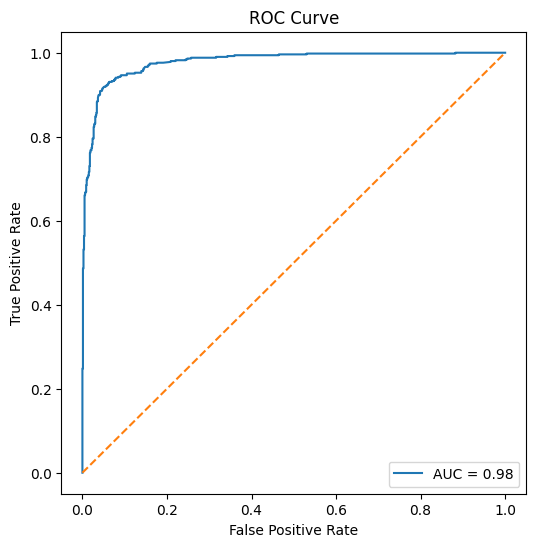

In [98]:
# Evaluate Logistic Regression (tuned)
# Ensure 'best_params' from GridSearchCV is available, otherwise use LogisticRegression(C=1, penalty='l1', solver='liblinear')
# If `best_params` was not run, you may need to define it here.
if 'best_params' in locals():
    evaluate_model(best_model, X_train_scaled, y_train, X_test_scaled, y_test, model_name="Logistic Regression (Tuned)")
else:
    print("Best Logistic Regression model not found. Please run the GridSearchCV cell first.")
    #lr_model = LogisticRegression(random_state=42) # Using default for demonstration if tuned not available
    evaluate_model(model_logistic, X_train_scaled, y_train, X_test_scaled, y_test, model_name="Logistic Regression (Default)")


--- Evaluating KNN (Optimal K=3) ---
Accuracy: 0.87
Confusion Matrix:
[[734  56]
 [116 388]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.90       790
           1       0.87      0.77      0.82       504

    accuracy                           0.87      1294
   macro avg       0.87      0.85      0.86      1294
weighted avg       0.87      0.87      0.87      1294

AUC: 0.9040737392003215


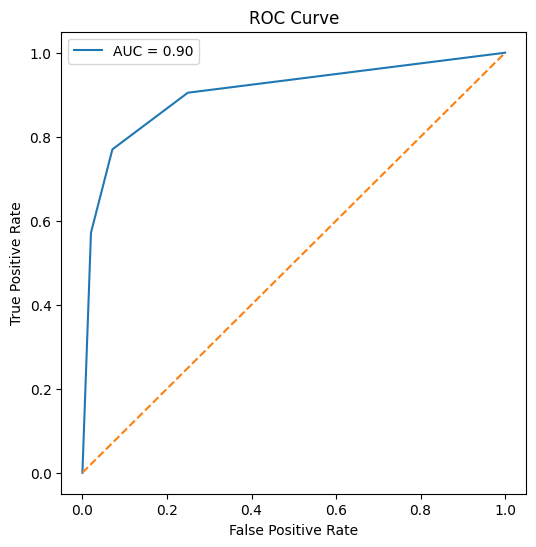

In [99]:
# Evaluate KNN (optimal K=3)
# Ensure 'best_k' is available, otherwise redefine it
if 'best_k' in locals():
    evaluate_model(knn_model_optimal, X_train_scaled, y_train, X_test_scaled, y_test, model_name="KNN (Optimal K=3)")
else:
    print("Optimal KNN model not found. Please run the KNN optimal K cell first.")
    # knn_model_default = KNeighborsClassifier(n_neighbors=5) # Using default for demonstration if optimal not available
    evaluate_model(knn_model_default, X_train_scaled, y_train, X_test_scaled, y_test, model_name="KNN (Default K=5)")


--- Evaluating Decision Tree (Gini, max_depth=3) ---
Accuracy: 0.88
Confusion Matrix:
[[776  14]
 [147 357]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.91       790
           1       0.96      0.71      0.82       504

    accuracy                           0.88      1294
   macro avg       0.90      0.85      0.86      1294
weighted avg       0.89      0.88      0.87      1294

AUC: 0.8488672895318465


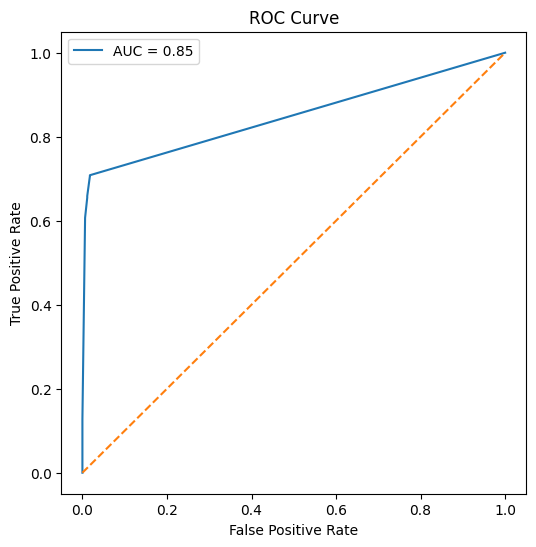

In [100]:
# Evaluate Decision Tree (using Gini with max_depth=3)
# Ensure 'dt_model_gini' is available, otherwise redefine it
if 'dt_model_gini' in locals():
    evaluate_model(dt_model_gini, X_train, y_train, X_test, y_test, model_name="Decision Tree (Gini, max_depth=3)")
else:
    print("Gini Decision Tree model not found. Please run the corresponding cell first.")
    dt_model_default = DecisionTreeClassifier(random_state=1) # Using default for demonstration if Gini not available
    evaluate_model(dt_model_default, X_train_, y_train, X_test, y_test, model_name="Decision Tree (Default)")


--- Evaluating Random Forest (Configured) ---
Accuracy: 0.89
Confusion Matrix:
[[730  60]
 [ 87 417]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       790
           1       0.87      0.83      0.85       504

    accuracy                           0.89      1294
   macro avg       0.88      0.88      0.88      1294
weighted avg       0.89      0.89      0.89      1294

AUC: 0.9502511553144466


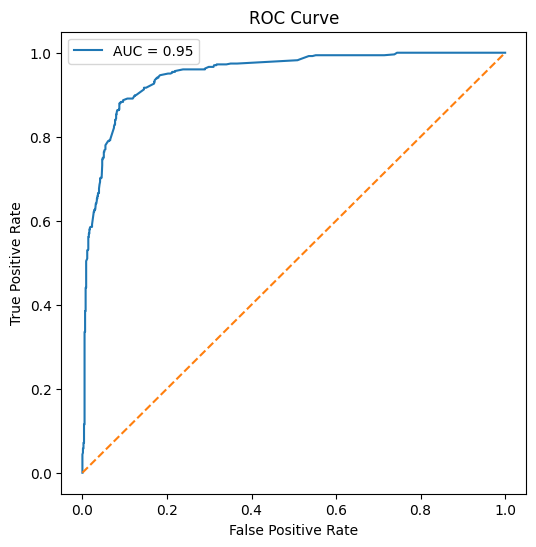

In [101]:
# Evaluate Random Forest (with specified hyperparameters)
# Ensure 'rf_classifier' is available (the instance, not the fitted model 'rf_model')
if 'rf_model_param' in locals():
    # Note: evaluate_model expects an unfitted model. We pass the configured classifier.
    evaluate_model(rf_model_param, X_train, y_train, X_test, y_test, model_name="Random Forest (Configured)")
else:
    print("Configured Random Forest classifier not found. Please run the corresponding cell first.")
    # rf_model_default = RandomForestClassifier(random_state=1) # Using default for demonstration if configured not available
    evaluate_model(rf_model_default, X_train, y_train, X_test, y_test, model_name="Random Forest (Default)")

# Gradient Boosting

Evaluate GradientBoost model

--- Evaluating Gradient Boosting (Default) ---
Accuracy: 0.94
Confusion Matrix:
[[762  28]
 [ 53 451]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       790
           1       0.94      0.89      0.92       504

    accuracy                           0.94      1294
   macro avg       0.94      0.93      0.93      1294
weighted avg       0.94      0.94      0.94      1294

AUC: 0.980795408880852


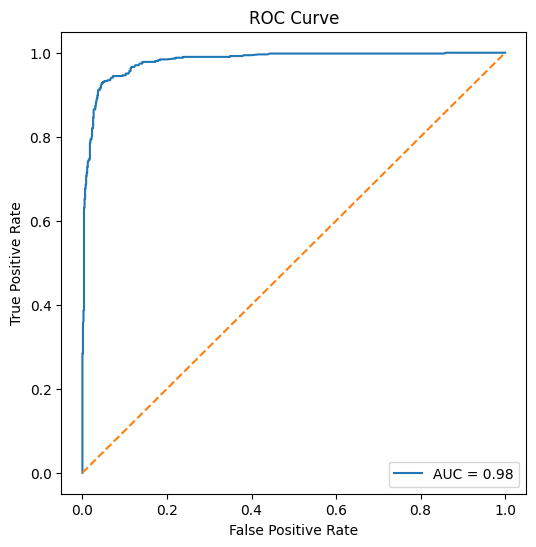

In [102]:
#GradientBoosting

gb_model_default = GradientBoostingClassifier(random_state=1)

gb_model_default.fit(X_train, y_train)

print("Evaluate GradientBoost model")

evaluate_model(gb_model_default, X_train, y_train, X_test, y_test, model_name="Gradient Boosting (Default)")



# XGBoost

Evaluate XGBoost model

--- Evaluating XGBoost (Default) ---
Accuracy: 0.90
Confusion Matrix:
[[766  24]
 [111 393]]
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       790
           1       0.94      0.78      0.85       504

    accuracy                           0.90      1294
   macro avg       0.91      0.87      0.89      1294
weighted avg       0.90      0.90      0.89      1294

AUC: 0.9534948262005223


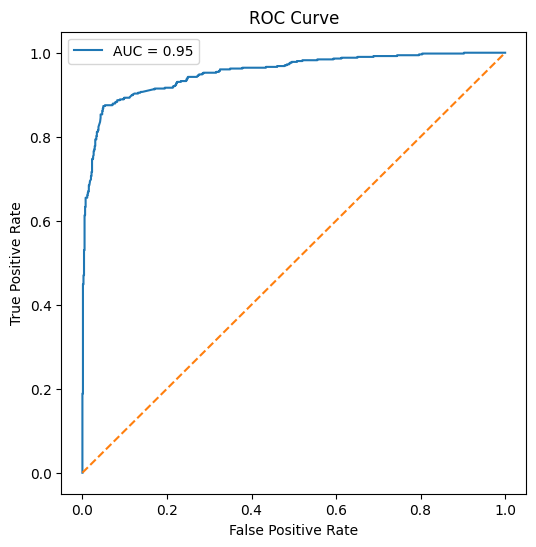

In [103]:
#XGBoost

xgb_model_default = XGBClassifier(random_state=1)

xgb_model_default.fit(X_train, y_train)

print("Evaluate XGBoost model")

evaluate_model(xgb_model_default, X_train, y_train, X_test_scaled, y_test, model_name="XGBoost (Default)")

# Adaboost

Evaluate Adaboost model

--- Evaluating Adaboost (Default) ---
Accuracy: 0.92
Confusion Matrix:
[[761  29]
 [ 79 425]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       790
           1       0.94      0.84      0.89       504

    accuracy                           0.92      1294
   macro avg       0.92      0.90      0.91      1294
weighted avg       0.92      0.92      0.92      1294

AUC: 0.9723741711874624


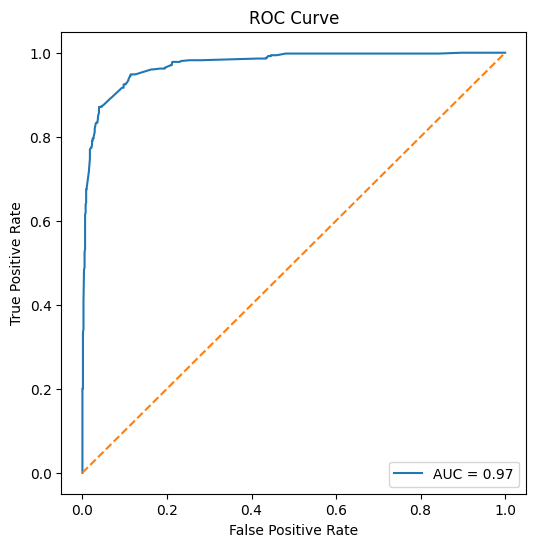

In [104]:
#Adaboost

ada_model_default = AdaBoostClassifier(random_state=1)

ada_model_default.fit(X_train, y_train)

print("Evaluate Adaboost model")

evaluate_model(ada_model_default, X_train, y_train, X_test, y_test, model_name="Adaboost (Default)")

# CatBoost

Learning rate set to 0.020784
0:	learn: 0.6695026	total: 49.3ms	remaining: 49.3s
1:	learn: 0.6471270	total: 52.2ms	remaining: 26.1s
2:	learn: 0.6231202	total: 54.9ms	remaining: 18.2s
3:	learn: 0.6026653	total: 57.4ms	remaining: 14.3s
4:	learn: 0.5826125	total: 59.8ms	remaining: 11.9s
5:	learn: 0.5621324	total: 62.3ms	remaining: 10.3s
6:	learn: 0.5471297	total: 64.9ms	remaining: 9.21s
7:	learn: 0.5304727	total: 67.5ms	remaining: 8.37s
8:	learn: 0.5152811	total: 70ms	remaining: 7.7s
9:	learn: 0.4980101	total: 72.2ms	remaining: 7.15s
10:	learn: 0.4856246	total: 74.7ms	remaining: 6.72s
11:	learn: 0.4714063	total: 77ms	remaining: 6.34s
12:	learn: 0.4587717	total: 79.6ms	remaining: 6.04s
13:	learn: 0.4480837	total: 82.1ms	remaining: 5.78s
14:	learn: 0.4372786	total: 84.7ms	remaining: 5.56s
15:	learn: 0.4255966	total: 87.3ms	remaining: 5.37s
16:	learn: 0.4151414	total: 89.8ms	remaining: 5.19s
17:	learn: 0.4053094	total: 92.2ms	remaining: 5.03s
18:	learn: 0.3952829	total: 94.7ms	remaining: 4.8

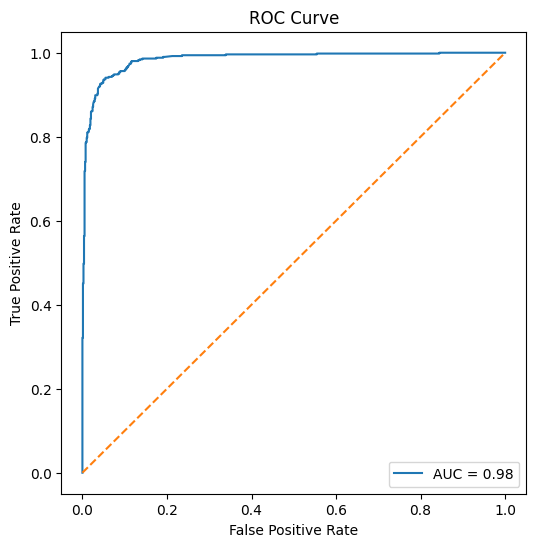

In [105]:
#CatBoost

cat_model_default = CatBoostClassifier(random_state=1)

cat_model_default.fit(X_train, y_train)

print("Evaluate CatBoost model")

evaluate_model(cat_model_default, X_train, y_train, X_test, y_test, model_name="CatBoost (Default)")


# ANN Model

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8826 - loss: 0.3069 - val_accuracy: 0.9246 - val_loss: 0.2179
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9449 - loss: 0.1570 - val_accuracy: 0.9295 - val_loss: 0.1940
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9541 - loss: 0.1291 - val_accuracy: 0.9324 - val_loss: 0.2115
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9594 - loss: 0.1160 - val_accuracy: 0.9227 - val_loss: 0.2046
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9640 - loss: 0.1067 - val_accuracy: 0.9266 - val_loss: 0.2474
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9667 - loss: 0.0948 - val_accuracy: 0.9198 - val_loss: 0.2362
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9696 - loss: 0.0843 - val_accuracy: 0.9246 - val_loss: 0.2315
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9720 - loss: 0.0767 - val_accuracy: 0.9217 - val_

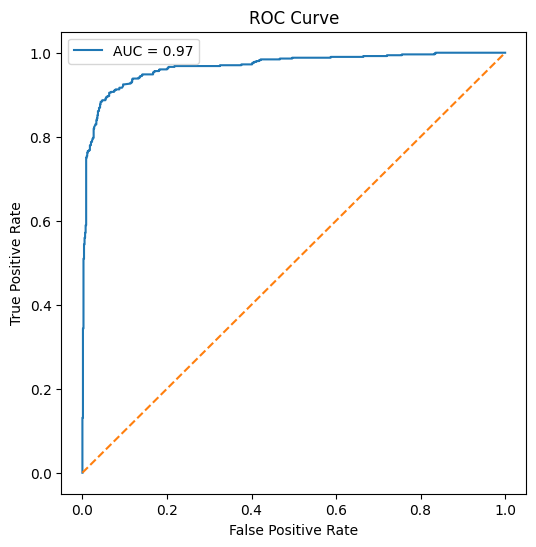

In [106]:
#ANN model

model_ann = Sequential()

# Added input_shape for the first layer, using the shape of the scaled training data
model_ann.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model_ann.add(Dense(64, activation='relu'))
model_ann.add(Dense(32, activation='relu'))
model_ann.add(Dense(1, activation='sigmoid'))

model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model with scaled training data
model_ann.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2)

print("Evaluate ANN model")

# # Evaluate the ANN model directly, as the generic evaluate_model function
# # is not designed for Keras model's predict output (which returns probabilities).
# print(f"\n--- Evaluating ANN ---")

# # Get probabilities from the model using scaled test data
y_prob_ann = model_ann.predict(X_test_scaled)

# # Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5

y_pred_ann = (y_prob_ann > 0.5).astype(int)

# probabilities = (y_prob_ann * 100).round(2)



# Evaluate performance with binary predictions
accuracy = accuracy_score(y_test, y_pred_ann)
print(f"Accuracy: {accuracy:.2f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_ann)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_ann)}")

# Calculate AUC score using probabilities
auc = roc_auc_score(y_test, y_prob_ann)
print("AUC:", auc)

# ROC values and plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_ann)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], '--')   # Random guessing line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Recall Score and Sample submission

In [108]:


models = {
    "Logistic Regression": (best_model, X_test_scaled),
    "KNN": (knn_model_optimal, X_test_scaled),
    "Decision Tree": (dt_model_gini, X_test),
    "Random Forest": (rf_model_param, X_test),
    "Gradient Boosting": (gb_model_default, X_test),
    "XGBoost": (xgb_model_default, X_test),
    "AdaBoost": (ada_model_default, X_test),
    "CatBoost": (cat_model_default, X_test),
}

results = []

for name, (model, validation_features) in models.items():
    predictions = model.predict(validation_features)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions, pos_label=1)
    })

# ANN evaluation
ann_predictions = (
    model_ann.predict(X_test_scaled, verbose=0).ravel() >= 0.5
).astype(int)

results.append({
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, ann_predictions),
    "Recall": recall_score(y_test, ann_predictions, pos_label=1)
})

results_df = pd.DataFrame(results).sort_values(
    ["Accuracy", "Recall"], ascending=False
).reset_index(drop=True)

display(results_df.style.format({"Accuracy": "{:.4f}", "Recall": "{:.4f}"}))

best_model_name = results_df.loc[0, "Model"]
print(f"Best model: {best_model_name}")
print(f"Accuracy: {results_df.loc[0, 'Accuracy']:.4f}")
print(f"Recall: {results_df.loc[0, 'Recall']:.4f}")

#Then run this cell to predict the provided test data and save the submission file. It ensures that Id and Converted are the only output columns.
# Save IDs before removing them from model features
submission_ids = df_test["Id"].copy()

# Match the training features exactly.
# This safely excludes Id and any accidental Converted column added during alignment.
X_submission = df_test.reindex(columns=X_full.columns, fill_value=0)

# Scale only for models trained with scaled inputs
X_submission_scaled = scaler.transform(X_submission)

# Predict using the selected best model
if best_model_name == "Logistic Regression":
    submission_predictions = best_model.predict(X_submission_scaled)

elif best_model_name == "KNN":
    submission_predictions = knn_model_optimal.predict(X_submission_scaled)

elif best_model_name == "Decision Tree":
    submission_predictions = dt_model_gini.predict(X_submission)

elif best_model_name == "Random Forest":
    submission_predictions = rf_model_param.predict(X_submission)

elif best_model_name == "Gradient Boosting":
    submission_predictions = gb_model_default.predict(X_submission)

elif best_model_name == "XGBoost":
    submission_predictions = xgb_model_default.predict(X_submission)

elif best_model_name == "AdaBoost":
    submission_predictions = ada_model_default.predict(X_submission)

elif best_model_name == "CatBoost":
    submission_predictions = cat_model_default.predict(X_submission)

elif best_model_name == "ANN":
    submission_predictions = (
        model_ann.predict(X_submission_scaled, verbose=0).ravel() >= 0.5
    ).astype(int)

# Create submission in exactly the required format
submission = pd.DataFrame({
    "Id": submission_ids,
    "Converted": submission_predictions.astype(int)
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print(f"\nSaved submission.csv with {len(submission)} rows.")

,Model,Accuracy,Recall
0,CatBoost,0.9436,0.9206
1,XGBoost,0.9420,0.9187
2,Gradient Boosting,0.9374,0.8948
3,Logistic Regression,0.9366,0.9008
4,ANN,0.9266,0.8770
5,AdaBoost,0.9165,0.8433
6,Random Forest,0.8864,0.8274
7,Decision Tree,0.8756,0.7083
8,KNN,0.8671,0.7698


Best model: CatBoost
Accuracy: 0.9436
Recall: 0.9206
     Id  Converted
0  8305          0
1  1591          1
2  8604          0
3  1333          0
4  4260          0

Saved submission.csv with 2772 rows.
